### 1.  H1: 22~04시 여부를 통제했을 때도, 주 활동시간 외 거래는 주 활동시간 내 거래보다 이상거래 가능성이 높다.

In [4]:
import sys

print(sys.executable)

c:\Users\splen\anaconda3\envs\fraud-fds\python.exe


In [5]:
import statsmodels
import statsmodels.formula.api as smf

print("statsmodels 버전:", statsmodels.__version__)
print("정상 연결 완료")

statsmodels 버전: 0.14.6
정상 연결 완료


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, norm
import statsmodels
import statsmodels.formula.api as smf


# 한글 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 현재 작업 폴더 확인
print("현재 작업 폴더:", Path.cwd())
print("statsmodels 버전:", statsmodels.__version__)


# 가능한 데이터 경로
candidate_paths = [
    Path("../data/fraudTrain.csv"),
    Path("data/fraudTrain.csv"),
    Path("../../data/fraudTrain.csv"),
    Path(
        r"C:\Users\splen\OneDrive\Desktop\BDAI_"
        r"\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv"
    ),
    Path("../BOOSTMAP/Fraud-FDS-Project/data/raw/fraudTrain.csv"),
    Path("../data/raw/fraudTrain.csv"),
    Path("data/raw/fraudTrain.csv")
]


# 실제 존재하는 경로 탐색
data_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "fraudTrain.csv를 찾지 못했습니다.\n"
        "현재 작업 폴더와 실제 데이터 위치를 확인해주세요."
    )


print("사용 데이터 경로:", data_path.resolve())


# 원본 데이터 불러오기
train = pd.read_csv(
    data_path,
    low_memory=False
)


# 불필요한 인덱스 열 제거
train = train.drop(
    columns=[
        col for col in train.columns
        if col.startswith("Unnamed")
    ],
    errors="ignore"
)


# 분석에 필요한 변수 확인
required_columns = [
    "cc_num",
    "trans_date_trans_time",
    "is_fraud"
]

missing_columns = [
    col for col in required_columns
    if col not in train.columns
]

if missing_columns:
    raise KeyError(
        f"필요한 변수가 없습니다: {missing_columns}"
    )


print("\n데이터 불러오기 완료")
print("데이터 크기:", train.shape)
print("전체 고객 수:", train["cc_num"].nunique())
print("전체 이상거래 건수:", train["is_fraud"].sum())
print(
    "전체 이상거래율:",
    f'{train["is_fraud"].mean() * 100:.4f}%'
)

display(train.head())

현재 작업 폴더: c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\검정
statsmodels 버전: 0.14.6
사용 데이터 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv

데이터 불러오기 완료
데이터 크기: (1296675, 22)
전체 고객 수: 983
전체 이상거래 건수: 7506
전체 이상거래율: 0.5789%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


# 1.

H0: 22~04시 여부를 통제했을 때, 주 활동시간 외 거래는 주 활동시간 내 거래보다 이상거래 가능성이 높지 않다.

(H₀: βoutside ≤ 0)

H1: 22~04시 여부를 통제했을 때도, 주 활동시간 외 거래는 주 활동시간 내 거래보다 이상거래 가능성이 높다.

(H₁: βoutside > 0)

In [ ]:
## 고객별 주 활동시간 생성
## 누적 거래 비중이 처음 80%에 도달할 때까지 주 활동시간으로 지정
## 정상거래 이력이 20건 이상인 고객만 분석

# 시간 분석에 필요한 열만 복사
# 원본 train은 변경되지 않음
time_base = train[
    [
        "cc_num",
        "trans_date_trans_time",
        "is_fraud"
    ]
].copy()


# 거래일시 변환
time_base["trans_date_trans_time"] = pd.to_datetime(
    time_base["trans_date_trans_time"],
    errors="coerce"
)

time_base = time_base.dropna(
    subset=[
        "cc_num",
        "trans_date_trans_time",
        "is_fraud"
    ]
).copy()


# 거래 시간 파생변수
time_base["trans_hour"] = (
    time_base["trans_date_trans_time"].dt.hour
)

time_base["is_fraud"] = (
    time_base["is_fraud"].astype(int)
)


# 정상거래만 추출
normal_time_history = time_base.loc[
    time_base["is_fraud"].eq(0)
].copy()


# 고객별 정상거래 건수
normal_customer_count = (
    normal_time_history
    .groupby("cc_num")
    .size()
    .rename("normal_transaction_count")
    .reset_index()
)


# 정상거래가 20건 이상인 고객
eligible_customer_ids = normal_customer_count.loc[
    normal_customer_count["normal_transaction_count"] >= 20,
    "cc_num"
]

print("전체 고객 수:", time_base["cc_num"].nunique())
print(
    "정상거래 20건 이상 고객 수:",
    eligible_customer_ids.nunique()
)
print(
    "제외 고객 수:",
    time_base["cc_num"].nunique()
    - eligible_customer_ids.nunique()
)

전체 고객 수: 983
정상거래 20건 이상 고객 수: 908
제외 고객 수: 75


In [ ]:
## 시간대별 누적 비중 계산

# 고객별·시간대별 정상거래 건수
normal_hour_profile = (
    normal_time_history.loc[
        normal_time_history["cc_num"].isin(
            eligible_customer_ids
        )
    ]
    .groupby(
        ["cc_num", "trans_hour"],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "normal_hour_transactions"
        }
    )
)


# 고객별 정상거래 총건수
normal_hour_total = (
    normal_hour_profile
    .groupby("cc_num", as_index=False)
    .agg(
        total_normal_transactions=(
            "normal_hour_transactions",
            "sum"
        )
    )
)

normal_hour_profile = normal_hour_profile.merge(
    normal_hour_total,
    on="cc_num",
    how="left"
)


# 시간대별 정상거래 비중
normal_hour_profile["hour_share"] = (
    normal_hour_profile["normal_hour_transactions"]
    / normal_hour_profile["total_normal_transactions"]
)


# 거래가 많은 시간부터 정렬
normal_hour_profile = normal_hour_profile.sort_values(
    [
        "cc_num",
        "normal_hour_transactions",
        "trans_hour"
    ],
    ascending=[
        True,
        False,
        True
    ]
).copy()


# 고객별 누적 거래 비중
normal_hour_profile["cumulative_hour_share"] = (
    normal_hour_profile
    .groupby("cc_num")["hour_share"]
    .cumsum()
)


# 해당 시간대를 포함하기 직전 누적 비중
normal_hour_profile["cumulative_share_before"] = (
    normal_hour_profile["cumulative_hour_share"]
    - normal_hour_profile["hour_share"]
)


# 누적 비중이 80%에 도달할 때까지 주 활동시간으로 지정
# 80%를 넘게 만드는 마지막 시간대도 포함
normal_hour_profile["is_active_hour_80"] = (
    normal_hour_profile["cumulative_share_before"] < 0.80
).astype(int)

display(normal_hour_profile.head(20))

,cc_num,trans_hour,normal_hour_transactions,total_normal_transactions,hour_share,cumulative_hour_share,cumulative_share_before,is_active_hour_80
13,60416207185,13,107,1509,0.070908,0.070908,0.000000,1
12,60416207185,12,105,1509,0.069583,0.140490,0.070908,1
19,60416207185,19,98,1509,0.064944,0.205434,0.140490,1
17,60416207185,17,95,1509,0.062956,0.268390,0.205434,1
21,60416207185,21,94,1509,0.062293,0.330683,0.268390,1
18,60416207185,18,83,1509,0.055003,0.385686,0.330683,1
15,60416207185,15,82,1509,0.054341,0.440027,0.385686,1
14,60416207185,14,79,1509,0.052353,0.492379,0.440027,1
16,60416207185,16,78,1509,0.051690,0.544069,0.492379,1
23,60416207185,23,78,1509,0.051690,0.595759,0.544069,1


In [ ]:
## 거래별 주 활동시간 이탈 여부 생성

# 정상거래가 20건 이상인 고객의 모든 거래
time_hypothesis_test = time_base.loc[
    time_base["cc_num"].isin(
        eligible_customer_ids
    )
].copy()


# 고객별 주 활동시간 정보 결합
time_hypothesis_test = time_hypothesis_test.merge(
    normal_hour_profile[
        [
            "cc_num",
            "trans_hour",
            "is_active_hour_80"
        ]
    ],
    on=[
        "cc_num",
        "trans_hour"
    ],
    how="left"
)


# 정상거래 이력에 없던 시간은 주 활동시간 밖으로 처리
time_hypothesis_test["is_active_hour_80"] = (
    time_hypothesis_test["is_active_hour_80"]
    .fillna(0)
    .astype(int)
)


# 주 활동시간 이탈 여부
# 0: 주 활동시간 안
# 1: 주 활동시간 밖
time_hypothesis_test["outside_active_hours_80"] = (
    1 - time_hypothesis_test["is_active_hour_80"]
)


# 22:00~04:59 여부
time_hypothesis_test["is_common_risk_time_22_04"] = (
    (time_hypothesis_test["trans_hour"] >= 22)
    | (time_hypothesis_test["trans_hour"] <= 3)
).astype(int)


print("분석 거래 건수:", len(time_hypothesis_test))
print(
    "분석 고객 수:",
    time_hypothesis_test["cc_num"].nunique()
)

display(
    time_hypothesis_test[
        [
            "cc_num",
            "trans_hour",
            "is_active_hour_80",
            "outside_active_hours_80",
            "is_common_risk_time_22_04",
            "is_fraud"
        ]
    ].head()
)

분석 거래 건수: 1295934
분석 고객 수: 908


,cc_num,trans_hour,is_active_hour_80,outside_active_hours_80,is_common_risk_time_22_04,is_fraud
0,2703186189652095,0,0,1,1,0
1,630423337322,0,1,0,1,0
2,38859492057661,0,1,0,1,0
3,3534093764340240,0,1,0,1,0
4,375534208663984,0,1,0,1,0


In [ ]:
## 네 집단별 이상거래율 확인

time_hypothesis_test["time_combination_group"] = np.select(
    [
        (
            time_hypothesis_test[
                "is_common_risk_time_22_04"
            ].eq(0)
            &
            time_hypothesis_test[
                "outside_active_hours_80"
            ].eq(0)
        ),
        (
            time_hypothesis_test[
                "is_common_risk_time_22_04"
            ].eq(0)
            &
            time_hypothesis_test[
                "outside_active_hours_80"
            ].eq(1)
        ),
        (
            time_hypothesis_test[
                "is_common_risk_time_22_04"
            ].eq(1)
            &
            time_hypothesis_test[
                "outside_active_hours_80"
            ].eq(0)
        ),
        (
            time_hypothesis_test[
                "is_common_risk_time_22_04"
            ].eq(1)
            &
            time_hypothesis_test[
                "outside_active_hours_80"
            ].eq(1)
        )
    ],
    [
        "일반시간·활동시간 안",
        "일반시간·활동시간 밖",
        "22~04시·활동시간 안",
        "22~04시·활동시간 밖"
    ],
    default="확인 필요"
)


group_order = [
    "일반시간·활동시간 안",
    "일반시간·활동시간 밖",
    "22~04시·활동시간 안",
    "22~04시·활동시간 밖"
]

time_hypothesis_test["time_combination_group"] = (
    pd.Categorical(
        time_hypothesis_test[
            "time_combination_group"
        ],
        categories=group_order,
        ordered=True
    )
)


time_group_summary = (
    time_hypothesis_test
    .groupby(
        "time_combination_group",
        observed=True
    )
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        customer_count=("cc_num", "nunique"),
        is_fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

time_group_summary["is_fraud_rate_pct"] = (
    time_group_summary["is_fraud_rate"] * 100
)

display(
    time_group_summary[
        [
            "time_combination_group",
            "total_transactions",
            "is_fraud_transactions",
            "customer_count",
            "is_fraud_rate_pct"
        ]
    ].round(4)
)

,time_combination_group,total_transactions,is_fraud_transactions,customer_count,is_fraud_rate_pct
0,일반시간·활동시간 안,823226,708,908,0.0860
1,일반시간·활동시간 밖,168460,329,908,0.1953
2,22~04시·활동시간 안,234321,3875,908,1.6537
3,22~04시·활동시간 밖,69927,1853,830,2.6499


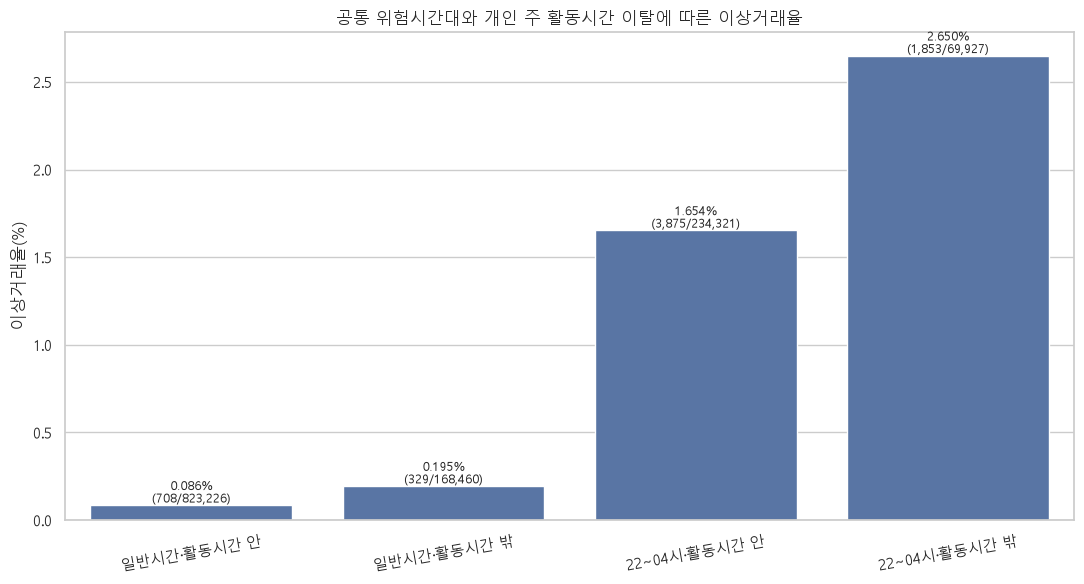

In [ ]:
## 시각화

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=time_group_summary,
    x="time_combination_group",
    y="is_fraud_rate_pct"
)

for index, row in time_group_summary.iterrows():
    ax.text(
        index,
        row["is_fraud_rate_pct"],
        (
            f'{row["is_fraud_rate_pct"]:.3f}%\n'
            f'({int(row["is_fraud_transactions"]):,}/'
            f'{int(row["total_transactions"]):,})'
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "공통 위험시간대와 개인 주 활동시간 이탈에 따른 이상거래율"
)
plt.xlabel("")
plt.ylabel("이상거래율(%)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [ ]:
time_contingency_table = pd.crosstab(
    time_hypothesis_test[
        "outside_active_hours_80"
    ],
    time_hypothesis_test["is_fraud"]
)

time_contingency_table = (
    time_contingency_table
    .reindex(
        index=[0, 1],
        columns=[0, 1],
        fill_value=0
    )
)

time_contingency_table.index = [
    "주 활동시간 안",
    "주 활동시간 밖"
]

time_contingency_table.columns = [
    "정상거래",
    "이상거래"
]

display(time_contingency_table)


chi2_statistic, chi2_pvalue, chi2_dof, expected = (
    chi2_contingency(
        time_contingency_table,
        correction=False
    )
)

print(f"카이제곱 통계량: {chi2_statistic:,.4f}")
print(f"자유도: {chi2_dof}")
print(f"p-value: {chi2_pvalue:.6g}")

,정상거래,이상거래
주 활동시간 안,1052964,4583
주 활동시간 밖,236205,2182


카이제곱 통계량: 870.1700
자유도: 1
p-value: 2.99664e-191


=> 단순 카이제곱 검정.(22~04시를 통제하지 않은 기초 검정)

In [ ]:
##핵심 검정: 조정 로지스틱 회귀
## 22-04시 여부를 통제한 뒤 outside_active_hours_80의 효과를 검정.
## 같은 고객이 여러 거래를 발생시키므로 cc_num 기준 군집표준오차를 적용.

adjusted_time_model = smf.logit(
    formula=(
        "is_fraud ~ "
        "outside_active_hours_80 "
        "+ is_common_risk_time_22_04"
    ),
    data=time_hypothesis_test
).fit(
    disp=0,
    cov_type="cluster",
    cov_kwds={
        "groups": time_hypothesis_test["cc_num"]
    }
)

print(adjusted_time_model.summary())

                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:              1295934
Model:                          Logit   Df Residuals:                  1295931
Method:                           MLE   Df Model:                            2
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1397
Time:                        21:42:57   Log-Likelihood:                -36391.
converged:                       True   LL-Null:                       -42299.
Covariance Type:              cluster   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.9745      0.042   -167.807      0.000      -7.056      -6.893
outside_active_hours_80       0.5314      0.035     14.980      0.000       0.462     

In [ ]:
## 오즈비와 단측 p-val 계산

coefficient_table = pd.DataFrame({
    "coef": adjusted_time_model.params,
    "std_error": adjusted_time_model.bse,
    "z_value": adjusted_time_model.tvalues,
    "p_value_two_sided": adjusted_time_model.pvalues
})

confidence_interval = adjusted_time_model.conf_int()

confidence_interval.columns = [
    "coef_ci_lower",
    "coef_ci_upper"
]

adjusted_logit_result = coefficient_table.join(
    confidence_interval
)

adjusted_logit_result["odds_ratio"] = np.exp(
    adjusted_logit_result["coef"]
)

adjusted_logit_result["or_ci_lower"] = np.exp(
    adjusted_logit_result["coef_ci_lower"]
)

adjusted_logit_result["or_ci_upper"] = np.exp(
    adjusted_logit_result["coef_ci_upper"]
)

# 방향가설 H1: 회귀계수 > 0
adjusted_logit_result[
    "p_value_one_sided_greater"
] = norm.sf(
    adjusted_logit_result["z_value"]
)

display(
    adjusted_logit_result[
        [
            "coef",
            "std_error",
            "z_value",
            "p_value_two_sided",
            "p_value_one_sided_greater",
            "odds_ratio",
            "or_ci_lower",
            "or_ci_upper"
        ]
    ].round(6)
)

,coef,std_error,z_value,p_value_two_sided,p_value_one_sided_greater,odds_ratio,or_ci_lower,or_ci_upper
Intercept,-6.974518,0.041563,-167.807334,0.0,1.0,0.000935,0.000862,0.001015
outside_active_hours_80,0.531372,0.035471,14.980349,0.0,0.0,1.701265,1.587007,1.823750
is_common_risk_time_22_04,2.872825,0.035766,80.321695,0.0,0.0,17.686910,16.489499,18.971272


In [ ]:
variable_name = "outside_active_hours_80"

outside_coef = adjusted_time_model.params[
    variable_name
]

outside_se = adjusted_time_model.bse[
    variable_name
]

outside_z = outside_coef / outside_se

outside_p_one_sided = norm.sf(outside_z)

outside_p_two_sided = adjusted_time_model.pvalues[
    variable_name
]

outside_or = np.exp(outside_coef)

outside_ci = adjusted_time_model.conf_int().loc[
    variable_name
]

outside_or_ci_lower = np.exp(
    outside_ci.iloc[0]
)

outside_or_ci_upper = np.exp(
    outside_ci.iloc[1]
)


print("주 활동시간 이탈 효과")
print("-" * 45)
print(f"회귀계수: {outside_coef:.6f}")
print(f"오즈비: {outside_or:.4f}")
print(
    "오즈비 95% 신뢰구간: "
    f"[{outside_or_ci_lower:.4f}, "
    f"{outside_or_ci_upper:.4f}]"
)
print(
    f"양측 p-value: "
    f"{outside_p_two_sided:.6g}"
)
print(
    f"단측 p-value: "
    f"{outside_p_one_sided:.6g}"
)


if (
    outside_coef > 0
    and outside_p_one_sided < 0.05
):
    print(
        "\n결론: 귀무가설을 기각한다.\n"
        "22~04시라는 공통 위험 시간대를 통제한 "
        "이후에도 주 활동시간 외 거래의 이상거래 "
        "가능성이 주 활동시간 내 거래보다 "
        "통계적으로 유의하게 높다."
    )
else:
    print(
        "\n결론: 귀무가설을 기각할 근거가 "
        "충분하지 않다.\n"
        "22~04시를 통제한 이후 개인의 주 활동시간 "
        "이탈이 추가적인 이상거래 위험을 설명한다고 "
        "보기 어렵다."
    )

주 활동시간 이탈 효과
---------------------------------------------
회귀계수: 0.531372
오즈비: 1.7013
오즈비 95% 신뢰구간: [1.5870, 1.8237]
양측 p-value: 9.86972e-51
단측 p-value: 4.93486e-51

결론: 귀무가설을 기각한다.
22~04시라는 공통 위험 시간대를 통제한 이후에도 주 활동시간 외 거래의 이상거래 가능성이 주 활동시간 내 거래보다 통계적으로 유의하게 높다.


- 회귀계수: 0.53
22~04시 여부를 동일하게 두었을 때, 해당 거래가 고객의 주 활동시간 안이 아니라 주 활동시간 밖에서 발생하면 이상거래 가능성이 증가하는 방향으로 나타났다. 회귀계수 0.531은 계산 과정에서 사용하는 로그오즈 단위이므로, 이상거래 확률이 53.1% 증가했다는 뜻은 아니다. 실제 효과의 크기는 회귀계수를 오즈비로 변환하여 해석한다.
- 오즈비 : 1.70 (이상거래가 발생할 가능성과 발생하지 않을 가능성의 비율)
22~04시 여부를 통제한 결과, 주 활동시간 밖에서 발생한 거래의 이상거래 오즈는 주 활동시간 안에서 발생한 거래보다 약 1.70배 높았다. 즉, 주 활동시간 이탈 거래의 이상거래 오즈가 약 70.1% 높게 나타났다.
이는 이상거래 확률이 70.1% 증가한다는 뜻은 아니고, 오즈가 증가한다는 의미이다.
- 오즈비 95% 신뢰구간 [1.5870, 1.8237]
22~04시 여부를 통제했을 때, 주 활동시간 밖 거래의 이상거래 오즈는 주 활동시간 안 거래보다 약 1.59배에서 1.82배 높은 수준으로 추정된다. 다시 말해, 이상거래 오즈가 최소 약 58.7%, 최대 약 82.4% 더 높을 가능성이 있다.
- 양측 p-value = 9.86972e-51
주 활동시간 밖 거래와 안 거래의 이상거래 위험이 같다고 가정했을 때, 현재처럼 큰 차이가 어느 방향으로든 관찰될 가능성은 매우 작았다. 양측 p-value가 0.05보다 훨씬 작으므로, 주 활동시간 이탈 여부에 따라 이상거래 위험에 차이가 없다는 귀무가설을 기각하였다.
- 단측 p-value = 4.93486e-51
주 활동시간 밖 거래의 이상거래 위험이 더 높지 않다고 가정했을 때, 현재처럼 활동시간 밖 거래에서 더 높은 위험이 관찰될 가능성은 매우 작았다. 단측 p-value가 0.05보다 훨씬 작으므로, 주 활동시간 밖 거래의 이상거래 위험이 더 높다는 방향가설이 지지되었다.

# 2.
귀무가설 H0	


고액 거래 중에서 평소 소액 결제를 하던 고객의 이상거래율은 그 외 고객의 이상거래율보다 높지 않다.

H₀: βlow_spend ≤ 0


대립가설 H1


고액 거래 중에서 평소 소액 결제를 하던 고객의 이상거래율은 그 외 고객의 이상거래율보다 높다.

H₁: βlow_spend > 0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, norm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 정상거래만 사용하여 고객의 평소 결제금액 계산
normal_amount_history = train.loc[
    train["is_fraud"].eq(0),
    ["cc_num", "amt"]
].dropna().copy()


# 고객별 정상거래 금액 프로필
customer_amount_profile = (
    normal_amount_history
    .groupby("cc_num", as_index=False)
    .agg(
        normal_transaction_count=("amt", "size"),
        normal_median_amt=("amt", "median"),
        normal_mean_amt=("amt", "mean")
    )
)


# 정상거래 이력 20건 이상인 고객만 선정
customer_amount_profile = customer_amount_profile.loc[
    customer_amount_profile["normal_transaction_count"] >= 20
].copy()


# 평소 소액 결제 고객 여부
# 1: 정상거래 중앙값이 44달러 이하
# 0: 정상거래 중앙값이 44달러 초과
customer_amount_profile["low_spend_customer"] = (
    customer_amount_profile["normal_median_amt"] <= 44
).astype(int)


print(
    "분석 대상 고객 수:",
    customer_amount_profile["cc_num"].nunique()
)

print(
    "평소 소액 결제 고객 수:",
    customer_amount_profile["low_spend_customer"].sum()
)

display(customer_amount_profile.head())

분석 대상 고객 수: 908
평소 소액 결제 고객 수: 499


,cc_num,normal_transaction_count,normal_median_amt,normal_mean_amt,low_spend_customer
0,60416207185,1509,36.66,55.098569,1
1,60422928733,1519,52.15,64.608308,0
2,60423098130,500,34.68,108.151100,1
3,60427851591,514,76.36,96.272023,0
4,60487002085,496,35.64,50.726028,1


In [ ]:
eligible_customer_ids = customer_amount_profile["cc_num"]

eligible_normal_amount = normal_amount_history.loc[
    normal_amount_history["cc_num"].isin(
        eligible_customer_ids
    )
].copy()


# 정상거래 금액 기준 상위 1% 경계
high_amount_threshold = (
    eligible_normal_amount["amt"].quantile(0.99)
)

print(
    "고액 거래 기준:",
    f"${high_amount_threshold:,.2f} 이상"
)

고액 거래 기준: $486.30 이상


In [ ]:
# 분석 대상 고객의 모든 거래
amount_hypothesis_test = train.loc[
    train["cc_num"].isin(
        eligible_customer_ids
    ),
    [
        "cc_num",
        "amt",
        "is_fraud"
    ]
].copy()


# 고객별 평소 결제 프로필 결합
amount_hypothesis_test = amount_hypothesis_test.merge(
    customer_amount_profile[
        [
            "cc_num",
            "normal_median_amt",
            "normal_transaction_count",
            "low_spend_customer"
        ]
    ],
    on="cc_num",
    how="left"
)


# 고액 거래 여부
amount_hypothesis_test["is_high_amount"] = (
    amount_hypothesis_test["amt"]
    >= high_amount_threshold
).astype(int)


# 고액 거래만 추출
high_amount_test = amount_hypothesis_test.loc[
    amount_hypothesis_test["is_high_amount"].eq(1)
].copy()


# 실제 거래금액 차이를 통제하기 위한 로그금액
high_amount_test["log_amt"] = np.log1p(
    high_amount_test["amt"]
)


print("전체 고액 거래 건수:", len(high_amount_test))
print(
    "고액 거래 고객 수:",
    high_amount_test["cc_num"].nunique()
)

display(high_amount_test.head())

전체 고액 거래 건수: 16161
고액 거래 고객 수: 906


,cc_num,amt,is_fraud,normal_median_amt,normal_transaction_count,low_spend_customer,is_high_amount,log_amt
138,4060579726528237,636.41,0,48.965,1534,0,1,6.457413
139,4186530744674,500.92,0,48.050,1572,0,1,6.218441
232,4311368326621416041,1055.47,0,38.305,1034,1,1,6.962688
286,5559857416065248,511.09,0,41.540,1551,1,1,6.238500
296,571844099986,909.66,0,49.425,1542,0,1,6.814170


In [ ]:
high_amount_group_summary = (
    high_amount_test
    .groupby(
        "low_spend_customer",
        as_index=False
    )
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        customer_count=("cc_num", "nunique"),
        is_fraud_rate=("is_fraud", "mean"),
        median_amt=("amt", "median"),
        mean_amt=("amt", "mean")
    )
)

high_amount_group_summary["고객 구분"] = (
    high_amount_group_summary["low_spend_customer"]
    .map({
        0: "그 외 고객",
        1: "평소 소액 결제 고객"
    })
)

high_amount_group_summary["is_fraud_rate_pct"] = (
    high_amount_group_summary["is_fraud_rate"] * 100
)

display(
    high_amount_group_summary[
        [
            "고객 구분",
            "total_transactions",
            "is_fraud_transactions",
            "customer_count",
            "is_fraud_rate_pct",
            "median_amt",
            "mean_amt"
        ]
    ].round(4)
)

,고객 구분,total_transactions,is_fraud_transactions,customer_count,is_fraud_rate_pct,median_amt,mean_amt
0,그 외 고객,8387,1358,407,16.1917,619.90,804.9011
1,평소 소액 결제 고객,7774,1911,499,24.5819,829.55,1080.9204


In [ ]:
overall_high_amount_rate = (
    high_amount_test["is_fraud"].mean()
)

print(
    "전체 고액 거래 이상거래율:",
    f"{overall_high_amount_rate * 100:.4f}%"
)

전체 고액 거래 이상거래율: 20.2277%


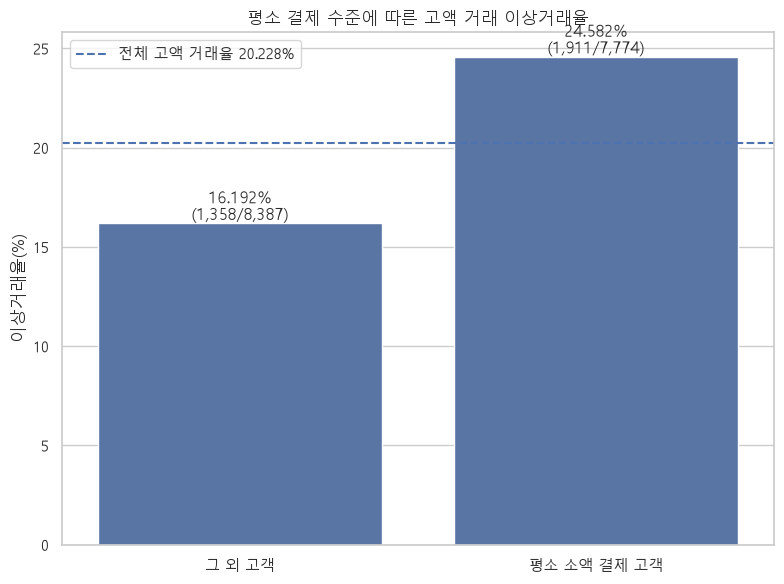

In [ ]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=high_amount_group_summary,
    x="고객 구분",
    y="is_fraud_rate_pct"
)

for index, row in high_amount_group_summary.iterrows():
    ax.text(
        index,
        row["is_fraud_rate_pct"],
        (
            f'{row["is_fraud_rate_pct"]:.3f}%\n'
            f'({int(row["is_fraud_transactions"]):,}/'
            f'{int(row["total_transactions"]):,})'
        ),
        ha="center",
        va="bottom"
    )

# 전체 고액 거래 이상거래율
plt.axhline(
    overall_high_amount_rate * 100,
    linestyle="--",
    label=(
        "전체 고액 거래율 "
        f"{overall_high_amount_rate * 100:.3f}%"
    )
)

plt.title("평소 결제 수준에 따른 고액 거래 이상거래율")
plt.xlabel("")
plt.ylabel("이상거래율(%)")
plt.legend()
plt.tight_layout()
plt.show()

카이제곱 검정 가설
H0
	

: 평소 소액 고객 여부와 고액 거래의 이상거래 여부는 관련이 없다.

H1
	

: 두 변수는 관련이 있다.

In [ ]:
amount_contingency_table = pd.crosstab(
    high_amount_test["low_spend_customer"],
    high_amount_test["is_fraud"]
).reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

amount_contingency_table.index = [
    "그 외 고객",
    "평소 소액 결제 고객"
]

amount_contingency_table.columns = [
    "정상거래",
    "이상거래"
]

display(amount_contingency_table)


chi2_statistic, chi2_pvalue, chi2_dof, expected = (
    chi2_contingency(
        amount_contingency_table,
        correction=False
    )
)

print(f"카이제곱 통계량: {chi2_statistic:,.4f}")
print(f"자유도: {chi2_dof}")
print(f"양측 p-value: {chi2_pvalue:.10g}")

,정상거래,이상거래
그 외 고객,7029,1358
평소 소액 결제 고객,5863,1911


카이제곱 통계량: 176.0072
자유도: 1
양측 p-value: 3.608058726e-40


In [ ]:
adjusted_amount_model = smf.logit(
    formula=(
        "is_fraud ~ "
        "low_spend_customer "
        "+ log_amt"
    ),
    data=high_amount_test
).fit(
    disp=0,
    cov_type="cluster",
    cov_kwds={
        "groups": high_amount_test["cc_num"]
    }
)

print(adjusted_amount_model.summary())

                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:                16161
Model:                          Logit   Df Residuals:                    16158
Method:                           MLE   Df Model:                            2
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                 0.01713
Time:                        21:42:57   Log-Likelihood:                -7998.3
converged:                       True   LL-Null:                       -8137.8
Covariance Type:              cluster   LLR p-value:                 2.820e-61
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.3627      0.331    -13.179      0.000      -5.012      -3.714
low_spend_customer     0.4260      0.076      5.630      0.000       0.278       0.574
log_amt             

In [ ]:
variable_name = "low_spend_customer"

low_spend_coef = adjusted_amount_model.params[
    variable_name
]

low_spend_se = adjusted_amount_model.bse[
    variable_name
]

low_spend_z = (
    low_spend_coef / low_spend_se
)

low_spend_p_two_sided = (
    adjusted_amount_model.pvalues[variable_name]
)

# 방향가설: 평소 소액 고객의 위험이 더 높다
low_spend_p_one_sided = norm.sf(
    low_spend_z
)

low_spend_or = np.exp(
    low_spend_coef
)

low_spend_ci = (
    adjusted_amount_model
    .conf_int()
    .loc[variable_name]
)

low_spend_or_ci_lower = np.exp(
    low_spend_ci.iloc[0]
)

low_spend_or_ci_upper = np.exp(
    low_spend_ci.iloc[1]
)


print("평소 소액 결제 고객 효과")
print("-" * 50)
print(f"회귀계수: {low_spend_coef:.6f}")
print(f"오즈비: {low_spend_or:.4f}")
print(
    "오즈비 95% 신뢰구간: "
    f"[{low_spend_or_ci_lower:.4f}, "
    f"{low_spend_or_ci_upper:.4f}]"
)
print(
    f"양측 p-value: "
    f"{low_spend_p_two_sided:.10g}"
)
print(
    f"단측 p-value: "
    f"{low_spend_p_one_sided:.10g}"
)


if (
    low_spend_coef > 0
    and low_spend_p_one_sided < 0.05
):
    print(
        "\n결론: 귀무가설을 기각한다.\n"
        "실제 고액 거래금액을 통제한 이후에도, "
        "평소 소액 결제를 하던 고객에게 발생한 "
        "고액 거래의 이상거래 가능성이 그 외 고객의 "
        "고액 거래보다 통계적으로 유의하게 높다."
    )
else:
    print(
        "\n결론: 귀무가설을 기각할 근거가 충분하지 않다.\n"
        "실제 고액 거래금액을 통제한 이후에는, "
        "평소 소액 결제 고객의 고액 거래가 "
        "추가적인 이상거래 위험을 설명한다고 "
        "보기 어렵다."
    )

평소 소액 결제 고객 효과
--------------------------------------------------
회귀계수: 0.425966
오즈비: 1.5311
오즈비 95% 신뢰구간: [1.3201, 1.7758]
양측 p-value: 1.799006894e-08
단측 p-value: 8.995034469e-09

결론: 귀무가설을 기각한다.
실제 고액 거래금액을 통제한 이후에도, 평소 소액 결제를 하던 고객에게 발생한 고액 거래의 이상거래 가능성이 그 외 고객의 고액 거래보다 통계적으로 유의하게 높다.


# 3.

귀무가설 H0
	

: 온라인과 오프라인 거래의 이상거래 위험은 차이가 없다.

대립가설 H1
	

: 온라인과 오프라인 거래의 이상거래 위험은 차이가 있다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, norm
import statsmodels.formula.api as smf


sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 분석 대상 카테고리
analysis_categories = [
    "shopping_net",
    "misc_net",
    "shopping_pos",
    "misc_pos"
]

# 필요한 열 확인
required_columns = [
    "cc_num",
    "merchant",
    "category",
    "amt",
    "is_fraud"
]

missing_columns = [
    column for column in required_columns
    if column not in train.columns
]

if missing_columns:
    raise KeyError(
        f"필요한 변수가 없습니다: {missing_columns}"
    )


# 원본 train을 변경하지 않고 분석용 데이터 복사
online_offline_test = train.loc[
    train["category"].isin(analysis_categories),
    required_columns
].dropna().copy()


# 온라인·오프라인 구분
online_offline_test["online_channel"] = (
    online_offline_test["category"]
    .isin(["shopping_net", "misc_net"])
    .astype(int)
)

online_offline_test["channel"] = (
    online_offline_test["online_channel"]
    .map({
        0: "오프라인",
        1: "온라인"
    })
)


# shopping과 misc 구분
online_offline_test["category_family"] = np.where(
    online_offline_test["category"].str.startswith("shopping"),
    "shopping",
    "misc"
)


# 거래금액 로그변환
online_offline_test["log_amt"] = np.log1p(
    online_offline_test["amt"]
)

online_offline_test["is_fraud"] = (
    online_offline_test["is_fraud"].astype(int)
)


print("분석 대상 거래 수:", f"{len(online_offline_test):,}")
print(
    "전체 거래 중 비율:",
    f"{len(online_offline_test) / len(train) * 100:.2f}%"
)
print(
    "분석 대상 가맹점 수:",
    online_offline_test["merchant"].nunique()
)
print(
    "분석 대상 고객 수:",
    online_offline_test["cc_num"].nunique()
)

display(online_offline_test.head())

분석 대상 거래 수: 357,157
전체 거래 중 비율: 27.54%
분석 대상 가맹점 수: 198
분석 대상 고객 수: 981


,cc_num,merchant,category,amt,is_fraud,online_channel,channel,category_family,log_amt
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,0,1,온라인,misc,1.786747
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,0,0,오프라인,misc,3.760269
8,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,0,0,오프라인,misc,1.662030
11,377234009633447,fraud_Kerluke-Abshire,shopping_net,7.77,0,1,온라인,shopping,2.171337
14,3514865930894695,fraud_Beier-Hyatt,shopping_pos,7.77,0,0,오프라인,shopping,2.171337


In [ ]:
category_summary = (
    online_offline_test
    .groupby("category", as_index=False)
    .agg(
        merchant_count=("merchant", "nunique"),
        customer_count=("cc_num", "nunique"),
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean"),
        median_amt=("amt", "median"),
        mean_amt=("amt", "mean")
    )
)

category_summary["is_fraud_rate_pct"] = (
    category_summary["is_fraud_rate"] * 100
)

display(
    category_summary[
        [
            "category",
            "merchant_count",
            "customer_count",
            "total_transactions",
            "is_fraud_transactions",
            "is_fraud_rate_pct",
            "median_amt",
            "mean_amt"
        ]
    ].round(4)
)

,category,merchant_count,customer_count,total_transactions,is_fraud_transactions,is_fraud_rate_pct,median_amt,mean_amt
0,misc_net,50,968,63287,915,1.4458,9.84,80.8651
1,misc_pos,50,921,79655,250,0.3139,13.92,62.8910
2,shopping_net,50,977,97543,1713,1.7561,8.44,88.4241
3,shopping_pos,50,961,116672,843,0.7225,7.76,79.7792


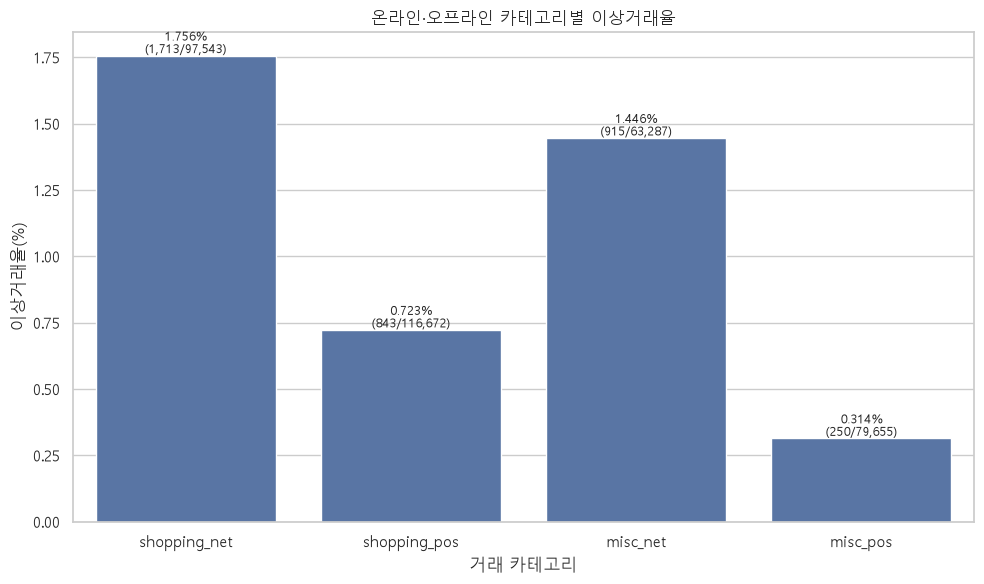

In [ ]:
category_order = [
    "shopping_net",
    "shopping_pos",
    "misc_net",
    "misc_pos"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_summary,
    x="category",
    y="is_fraud_rate_pct",
    order=category_order
)

for bar, category in zip(
    ax.patches,
    category_order
):
    row = category_summary.loc[
        category_summary["category"].eq(category)
    ].iloc[0]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        (
            f'{row["is_fraud_rate_pct"]:.3f}%\n'
            f'({int(row["is_fraud_transactions"]):,}/'
            f'{int(row["total_transactions"]):,})'
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("온라인·오프라인 카테고리별 이상거래율")
plt.xlabel("거래 카테고리")
plt.ylabel("이상거래율(%)")
plt.tight_layout()
plt.show()

In [ ]:
channel_summary = (
    online_offline_test
    .groupby(
        ["online_channel", "channel"],
        as_index=False
    )
    .agg(
        merchant_count=("merchant", "nunique"),
        customer_count=("cc_num", "nunique"),
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean"),
        median_amt=("amt", "median"),
        mean_amt=("amt", "mean")
    )
)

channel_summary["is_fraud_rate_pct"] = (
    channel_summary["is_fraud_rate"] * 100
)

display(
    channel_summary[
        [
            "channel",
            "merchant_count",
            "customer_count",
            "total_transactions",
            "is_fraud_transactions",
            "is_fraud_rate_pct",
            "median_amt",
            "mean_amt"
        ]
    ].round(4)
)

,channel,merchant_count,customer_count,total_transactions,is_fraud_transactions,is_fraud_rate_pct,median_amt,mean_amt
0,오프라인,100,963,196327,1093,0.5567,8.66,72.9272
1,온라인,100,980,160830,2628,1.6340,8.91,85.4496


In [ ]:
channel_contingency_table = pd.crosstab(
    online_offline_test["online_channel"],
    online_offline_test["is_fraud"]
).reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

channel_contingency_table.index = [
    "오프라인",
    "온라인"
]

channel_contingency_table.columns = [
    "정상거래",
    "이상거래"
]

display(channel_contingency_table)


chi2_statistic, chi2_pvalue, chi2_dof, expected = (
    chi2_contingency(
        channel_contingency_table,
        correction=False
    )
)

print(f"카이제곱 통계량: {chi2_statistic:,.4f}")
print(f"자유도: {chi2_dof}")
print(f"양측 p-value: {chi2_pvalue:.10g}")

if chi2_pvalue < 0.05:
    print(
        "\n결론: 귀무가설을 기각한다. "
        "온라인·오프라인 여부와 이상거래 여부 사이에는 "
        "통계적으로 유의한 관련이 있다."
    )
else:
    print(
        "\n결론: 귀무가설을 기각할 근거가 충분하지 않다. "
        "온라인·오프라인 여부에 따른 이상거래율 차이가 "
        "통계적으로 유의하다고 보기 어렵다."
    )

,정상거래,이상거래
오프라인,195234,1093
온라인,158202,2628


카이제곱 통계량: 995.1958
자유도: 1
양측 p-value: 1.988522311e-218

결론: 귀무가설을 기각한다. 온라인·오프라인 여부와 이상거래 여부 사이에는 통계적으로 유의한 관련이 있다.


In [ ]:
channel_model = smf.logit(
    formula=(
        "is_fraud ~ "
        "online_channel "
        '+ C(category_family, Treatment(reference="shopping")) '
        "+ log_amt"
    ),
    data=online_offline_test
).fit(
    disp=0,
    cov_type="cluster",
    cov_kwds={
        "groups": online_offline_test["cc_num"]
    }
)

print(channel_model.summary())

                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:               357157
Model:                          Logit   Df Residuals:                   357153
Method:                           MLE   Df Model:                            3
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.4952
Time:                        21:42:59   Log-Likelihood:                -10442.
converged:                       True   LL-Null:                       -20685.
Covariance Type:              cluster   LLR p-value:                     0.000
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     -15.7754      0.307    -51.415      0.000     -16.

In [ ]:
variable_name = "online_channel"

online_coef = channel_model.params[
    variable_name
]

online_se = channel_model.bse[
    variable_name
]

online_z = (
    online_coef / online_se
)

online_p_two_sided = channel_model.pvalues[
    variable_name
]

# 방향가설: 온라인 위험이 오프라인보다 높다
online_p_one_sided = norm.sf(
    online_z
)

online_or = np.exp(
    online_coef
)

online_ci = (
    channel_model
    .conf_int()
    .loc[variable_name]
)

online_or_ci_lower = np.exp(
    online_ci.iloc[0]
)

online_or_ci_upper = np.exp(
    online_ci.iloc[1]
)


print("온라인 거래 효과")
print("-" * 50)
print(f"회귀계수: {online_coef:.6f}")
print(f"오즈비: {online_or:.4f}")
print(
    "오즈비 95% 신뢰구간: "
    f"[{online_or_ci_lower:.4f}, "
    f"{online_or_ci_upper:.4f}]"
)
print(
    "양측 p-value:",
    f"{online_p_two_sided:.10g}"
)
print(
    "단측 p-value:",
    f"{online_p_one_sided:.10g}"
)


# 양측검정 결론
if online_p_two_sided < 0.05:
    if online_coef > 0:
        direction_text = (
            "온라인 거래의 이상거래 가능성이 "
            "오프라인보다 높은 방향이다."
        )
    else:
        direction_text = (
            "온라인 거래의 이상거래 가능성이 "
            "오프라인보다 낮은 방향이다."
        )

    print(
        "\n양측검정 결론: 귀무가설을 기각한다.\n"
        "거래금액과 shopping·misc 차이를 통제한 이후에도 "
        "온라인·오프라인 여부에 따른 이상거래 위험의 "
        f"차이가 통계적으로 유의하다. {direction_text}"
    )
else:
    print(
        "\n양측검정 결론: 귀무가설을 기각할 근거가 "
        "충분하지 않다.\n"
        "거래금액과 shopping·misc 차이를 통제한 이후에는 "
        "온라인·오프라인 여부가 추가적인 이상거래 위험을 "
        "설명한다고 보기 어렵다."
    )


# 온라인이 더 위험하다는 방향가설 결론
if (
    online_coef > 0
    and online_p_one_sided < 0.05
):
    print(
        "\n방향가설 결론: "
        "온라인 거래의 이상거래 위험이 오프라인보다 "
        "높다는 가설이 지지된다."
    )
else:
    print(
        "\n방향가설 결론: "
        "온라인 거래가 오프라인보다 더 위험하다는 "
        "가설을 지지할 근거가 충분하지 않다."
    )

온라인 거래 효과
--------------------------------------------------
회귀계수: 1.060256
오즈비: 2.8871
오즈비 95% 신뢰구간: [2.6154, 3.1870]
양측 p-value: 3.692810096e-98
단측 p-value: 1.846405048e-98

양측검정 결론: 귀무가설을 기각한다.
거래금액과 shopping·misc 차이를 통제한 이후에도 온라인·오프라인 여부에 따른 이상거래 위험의 차이가 통계적으로 유의하다. 온라인 거래의 이상거래 가능성이 오프라인보다 높은 방향이다.

방향가설 결론: 온라인 거래의 이상거래 위험이 오프라인보다 높다는 가설이 지지된다.


# is_shopping vs is_online 무엇이 더 강력한 변수일까

In [ ]:

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 원본 train은 변경하지 않음
channel_analysis = train.copy()

shopping_categories = [
    "shopping_net",
    "shopping_pos",
    "misc_net",
    "misc_pos"
]

online_categories = [
    "misc_net",
    "shopping_net",
    "grocery_net"
]

channel_analysis["is_shopping"] = (
    channel_analysis["category"]
    .isin(shopping_categories)
    .astype("int8")
)

channel_analysis["is_online"] = (
    channel_analysis["category"]
    .isin(online_categories)
    .astype("int8")
)


def compare_binary_fraud_risk(data, variable):
    summary = (
        data.groupby(variable)["is_fraud"]
        .agg(
            transaction_count="size",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .reindex([0, 1], fill_value=0)
    )

    rate_0 = summary.loc[0, "fraud_rate"]
    rate_1 = summary.loc[1, "fraud_rate"]

    risk_difference = rate_1 - rate_0
    risk_ratio = rate_1 / rate_0 if rate_0 > 0 else np.nan

    contingency_table = pd.crosstab(
        data[variable],
        data["is_fraud"]
    ).reindex(
        index=[0, 1],
        columns=[0, 1],
        fill_value=0
    )

    chi2, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    return {
        "variable": variable,
        "non_group_transactions": int(
            summary.loc[0, "transaction_count"]
        ),
        "group_transactions": int(
            summary.loc[1, "transaction_count"]
        ),
        "fraud_rate_0_pct": rate_0 * 100,
        "fraud_rate_1_pct": rate_1 * 100,
        "risk_difference_ppt": risk_difference * 100,
        "risk_ratio": risk_ratio,
        "chi2": chi2,
        "p_value": p_value
    }


channel_comparison = pd.DataFrame([
    compare_binary_fraud_risk(
        channel_analysis,
        "is_shopping"
    ),
    compare_binary_fraud_risk(
        channel_analysis,
        "is_online"
    )
])

display(
    channel_comparison.round({
        "fraud_rate_0_pct": 4,
        "fraud_rate_1_pct": 4,
        "risk_difference_ppt": 4,
        "risk_ratio": 3,
        "chi2": 3,
        "p_value": 8
    })
)

#1. 1과 0의 이상거래율
#2. 이상거래율 차이
#3. 위험비율(Risk Ratio)
#4. 카이제곱 검정 p-value
#5. 각 집단의 거래 건수

,variable,non_group_transactions,group_transactions,fraud_rate_0_pct,fraud_rate_1_pct,risk_difference_ppt,risk_ratio,chi2,p_value
0,is_shopping,939518,357157,0.4029,1.0418,0.6390,2.586,1834.758,0.0
1,is_online,1090393,206282,0.4351,1.3389,0.9039,3.078,2460.896,0.0


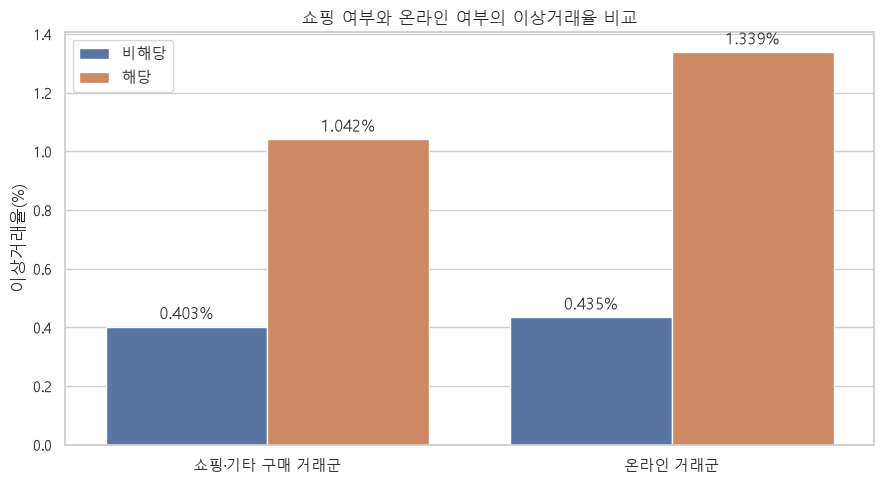

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plot_data = channel_comparison.copy()

plot_data["variable_label"] = plot_data["variable"].map({
    "is_shopping": "쇼핑·기타 구매 거래군",
    "is_online": "온라인 거래군"
})

plot_data = plot_data.melt(
    id_vars="variable_label",
    value_vars=[
        "fraud_rate_0_pct",
        "fraud_rate_1_pct"
    ],
    var_name="group",
    value_name="fraud_rate_pct"
)

plot_data["group"] = plot_data["group"].map({
    "fraud_rate_0_pct": "비해당",
    "fraud_rate_1_pct": "해당"
})

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_data,
    x="variable_label",
    y="fraud_rate_pct",
    hue="group"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f%%",
        padding=3
    )

plt.title("쇼핑 여부와 온라인 여부의 이상거래율 비교")
plt.xlabel("")
plt.ylabel("이상거래율(%)")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 가설 1 보완 검증 — "심야 여부만으로 개별 사기거래를 충분히 구분할 수 있는가?"
# =========================================================

import pandas as pd

TARGET = "is_fraud"

# ------------------------------------------------------------
# trans_hour 없으면 trans_date_trans_time에서 생성
# ------------------------------------------------------------

if "trans_hour" not in train.columns:
    train["trans_date_trans_time"] = pd.to_datetime(
        train["trans_date_trans_time"]
    )
    train["trans_hour"] = train["trans_date_trans_time"].dt.hour

if "is_night" not in train.columns:
    train["is_night"] = train["trans_hour"].apply(
        lambda h: 1 if (h >= 22 or h < 4) else 0
    )

# ------------------------------------------------------------
# 2x2 표 (심야 여부 x 실제 이상거래 여부)
# ------------------------------------------------------------

TP = int(((train["is_night"] == 1) & (train[TARGET] == 1)).sum())   # 심야 · 실제 사기
FP = int(((train["is_night"] == 1) & (train[TARGET] == 0)).sum())   # 심야 · 실제 정상
FN = int(((train["is_night"] == 0) & (train[TARGET] == 1)).sum())   # 주간 · 실제 사기
TN = int(((train["is_night"] == 0) & (train[TARGET] == 0)).sum())   # 주간 · 실제 정상

print("=" * 60)
print("2x2 표 (심야 여부 x 실제 이상거래)")
print("=" * 60)
print(f"심야·실제사기(TP): {TP:,}")
print(f"심야·실제정상(FP): {FP:,}")
print(f"주간·실제사기(FN): {FN:,}")
print(f"주간·실제정상(TN): {TN:,}")

# ------------------------------------------------------------
# 민감도 / 특이도 / 양성예측도(PPV) / 음성예측도(NPV)
# ------------------------------------------------------------

전체_사기율 = train[TARGET].mean()
민감도 = TP / (TP + FN)          # 실제 사기 중 심야로 잡아낸 비율 (=Recall)
특이도 = TN / (TN + FP)          # 실제 정상 중 주간으로 맞게 걸러낸 비율
양성예측도 = TP / (TP + FP)       # 심야로 예측했을 때 실제 사기일 확률 (=Precision, PPV)
음성예측도 = TN / (TN + FN)       # 주간으로 예측했을 때 실제 정상일 확률

print("\n" + "=" * 60)
print("가설 1-② 검증: 심야 여부의 개별 판별 성능")
print("=" * 60)
print(f"전체 사기 유병률(base rate): {전체_사기율:.4%}")
print(f"민감도(Sensitivity, Recall) : {민감도:.4%}")
print(f"특이도(Specificity)         : {특이도:.4%}")
print(f"양성예측도(PPV, Precision)  : {양성예측도:.4%}")
print(f"음성예측도(NPV)             : {음성예측도:.4%}")

print("\n해석:")
print(f"- 심야 여부는 사기의 {민감도:.1%}를 잡아내지만(민감도 높음),")
print(f"  심야로 판단한 거래 중 실제 사기는 {양성예측도:.1%}에 불과함(PPV 낮음).")
print("- 사기가 희귀사건(낮은 유병률)이기 때문에 생기는 전형적 현상으로,")
print("  통계적으로 유의하고 오즈비가 커도(18.45배) 개별 거래 판별에는")
print("  충분하지 않다는 근거가 됨.")

2x2 표 (심야 여부 x 실제 이상거래)
심야·실제사기(TP): 6,362
심야·실제정상(FP): 298,520
주간·실제사기(FN): 1,144
주간·실제정상(TN): 990,649

가설 1-② 검증: 심야 여부의 개별 판별 성능
전체 사기 유병률(base rate): 0.5789%
민감도(Sensitivity, Recall) : 84.7589%
특이도(Specificity)         : 76.8440%
양성예측도(PPV, Precision)  : 2.0867%
음성예측도(NPV)             : 99.8847%

해석:
- 심야 여부는 사기의 84.8%를 잡아내지만(민감도 높음),
  심야로 판단한 거래 중 실제 사기는 2.1%에 불과함(PPV 낮음).
- 사기가 희귀사건(낮은 유병률)이기 때문에 생기는 전형적 현상으로,
  통계적으로 유의하고 오즈비가 커도(18.45배) 개별 거래 판별에는
  충분하지 않다는 근거가 됨.


In [ ]:
# =========================================================
# 가설 2 보완 검증 — "위험은 금액에 따라 단조 증가가 아니라 특정 구간에 집중되는가?"
# - 기존 Mann-Whitney U(슬라이드 17)는 ①(이상거래 금액이 전반적으로 높다)만 검증
# - 이 코드는 ②(금액 구간별로 위험이 비선형적으로 집중되는가)를 검증
# - 가설 3과 동일한 방법(카이제곱 + Cramér's V)으로 통계적 일관성 유지
# =========================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

TARGET = "is_fraud"
data = train  # df를 쓰는 노트북이면 이 줄만 data = df 로 변경

# ------------------------------------------------------------
# 1. EDA에서 확인한 집중 구간을 반영한 금액 구간화
#    ($300대, $700~1,100 집중 구간을 각각 별도 구간으로 분리)
# ------------------------------------------------------------

bin_edges = [0, 100, 300, 400, 500, 700, 1100, np.inf]
bin_labels = [
    "0~100", "100~300", "300~400", "400~500",
    "500~700", "700~1,100", "1,100~"
]

data["amt_bin"] = pd.cut(
    data["amt"],
    bins=bin_edges,
    labels=bin_labels,
    right=False
)

# ------------------------------------------------------------
# 2. 구간별 이상거래율 표 (비선형 패턴을 직접 보여주는 근거)
# ------------------------------------------------------------

구간별_요약 = data.groupby("amt_bin", observed=True)[TARGET].agg(
    거래건수="count", 이상거래건수="sum"
)
구간별_요약["이상거래율(%)"] = (
    구간별_요약["이상거래건수"] / 구간별_요약["거래건수"] * 100
).round(4)

print("=" * 60)
print("금액 구간별 이상거래율")
print("=" * 60)
print(구간별_요약.to_string())

# ------------------------------------------------------------
# 3. 카이제곱 검정 — 금액구간과 이상거래 여부가 관련 있는가
# ------------------------------------------------------------

교차표 = pd.crosstab(data["amt_bin"], data[TARGET])
chi2, p_value, dof, expected = chi2_contingency(교차표)

print("\n" + "=" * 60)
print("카이제곱 검정 (amt_bin x is_fraud)")
print("=" * 60)
print(f"카이제곱 통계량: {chi2:.4f}")
print(f"자유도: {dof}")
print(f"p-value: {p_value}")

min_expected = expected.min()
print(f"\n최소 기대빈도: {min_expected:.2f}")
if min_expected < 5:
    print("⚠️ 기대빈도 5 미만인 셀 존재 — 구간을 더 크게 합쳐야 할 수 있음")
else:
    print("✅ 모든 기대빈도가 5 이상으로 카이제곱 조건 충족")

if p_value < 0.05:
    print("✅ 귀무가설 기각: 금액 구간과 이상거래 여부는 관련 있음")
else:
    print("❌ 귀무가설 기각 실패")

# ------------------------------------------------------------
# 4. Cramér's V (효과크기) — 가설 3과 동일한 지표로 비교 가능하게
# ------------------------------------------------------------

n = 교차표.sum().sum()
min_dim = min(교차표.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"\nCramér's V: {cramers_v:.4f}")
if cramers_v < 0.1:
    print("→ 작은 효과크기")
elif cramers_v < 0.3:
    print("→ 중간 효과크기")
else:
    print("→ 큰 효과크기")

print("\n해석:")
print("- 카이제곱 검정으로 금액 구간과 이상거래 여부의 통계적 관련성을 확인.")
print("- 구간별 이상거래율 표에서 특정 구간(예: 300~400, 700~1,100)이")
print("  주변 구간보다 이상거래율이 높게 튀는지 확인 → 단조 증가가 아닌")
print("  비선형·구간 집중 패턴을 정량적으로 뒷받침.")

금액 구간별 이상거래율
              거래건수  이상거래건수  이상거래율(%)
amt_bin                             
0~100      1061728    1652    0.1556
100~300     204648     945    0.4618
300~400       8600    1160   13.4884
400~500       6068     101    1.6645
500~700       6503     261    4.0135
700~1,100     6324    3083   48.7508
1,100~        2804     304   10.8417

카이제곱 검정 (amt_bin x is_fraud)
카이제곱 통계량: 289836.6748
자유도: 6
p-value: 0.0

최소 기대빈도: 16.23
✅ 모든 기대빈도가 5 이상으로 카이제곱 조건 충족
✅ 귀무가설 기각: 금액 구간과 이상거래 여부는 관련 있음

Cramér's V: 0.4728
→ 큰 효과크기

해석:
- 카이제곱 검정으로 금액 구간과 이상거래 여부의 통계적 관련성을 확인.
- 구간별 이상거래율 표에서 특정 구간(예: 300~400, 700~1,100)이
  주변 구간보다 이상거래율이 높게 튀는지 확인 → 단조 증가가 아닌
  비선형·구간 집중 패턴을 정량적으로 뒷받침.
